In [1]:
import os 
import numpy as np 
import pandas as pd 
import networkx as nx
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.spatial import distance
from scipy.spatial.distance import pdist
from IPython.display import display, HTML
from scipy.spatial.distance import squareform

## Build the PPI similarity network 

In [4]:
zero = pd.read_csv('/home/savvy/PROJECTS/PHD/DATA/Network_Analysis/tarassov/zero.csv')
ppi = pd.read_csv('/home/savvy/PROJECTS/PHD/piQTL-SerohijosLab/data/pipeline/PPI_reference_barcodes.csv')

In [5]:
zero

,PPI_1,PPI_2,Prot_1A,Prot_1B,Prot_2A,Prot_2B,distance
0,ERG27:ACF2,TGL4:ACF2,ERG27,ACF2,TGL4,ACF2,0.0
1,ERG27:ACF2,SNA3:ACF2,ERG27,ACF2,SNA3,ACF2,0.0
2,ERG27:ACF2,ERG7:ERG27,ERG27,ACF2,ERG7,ERG27,0.0
3,ERG27:ACF2,ACF2:SEL1,ERG27,ACF2,ACF2,SEL1,0.0
4,ERG27:ACF2,YEH1:ERG27,ERG27,ACF2,YEH1,ERG27,0.0
...,...,...,...,...,...,...,...
37645,ARF1:ERV29,ARF1:SNA3,ARF1,ERV29,ARF1,SNA3,0.0
37646,ARF1:ERV29,ARF1:ALO1,ARF1,ERV29,ARF1,ALO1,0.0
37647,ARF1:SNA3,ARF1:ALO1,ARF1,SNA3,ARF1,ALO1,0.0
37648,ADH4:SWI6,COX23:SWI6,ADH4,SWI6,COX23,SWI6,0.0


In [6]:
#### Some PPI bait and prey might be reversed in the Chloe's network, so we take account of both versions
PPI_1 =[ ppi['ppi'][idx] for idx in ppi['ppi'].index ]
PPI_2 = [ f'{ppi["ppi"][idx].split(":")[1]}:{ppi["ppi"][idx].split(":")[0]}' for idx in ppi['ppi'].index ]
all_PPIs = [*PPI_1, *PPI_2]

In [7]:
#### Collect the edges that involves one of our 61 PPIs of interest
piQTL_PPIs = zero[(zero['PPI_1'].isin(all_PPIs))|(zero['PPI_2'].isin(all_PPIs)) ][['PPI_1', 'PPI_2']].values

In [8]:
pd.DataFrame(piQTL_PPIs, columns=['PPI_1', 'PPI_2']) # .to_csv('../results/09_PPI_network/PPI_similarity_network.csv', index=False)

,PPI_1,PPI_2
0,ERG27:ACF2,TGL4:ACF2
1,ERG27:ACF2,SNA3:ACF2
2,ERG27:ACF2,ERG7:ERG27
3,ERG27:ACF2,ACF2:SEL1
4,ERG27:ACF2,YEH1:ERG27
...,...,...
3120,MID2:MYO5,TPO1:MID2
3121,FTR1:MID2,TPO1:MID2
3122,TPO1:MID2,TPO1:RSA3
3123,PLM2:SNA3,ARF1:SNA3


In [9]:
#### Build the PPI similarity network
G = nx.Graph()
G.add_edges_from(piQTL_PPIs)

In [10]:
#### Stats of nodes and edges 
len(G.nodes()), len(G.edges())

(742, 3125)

61


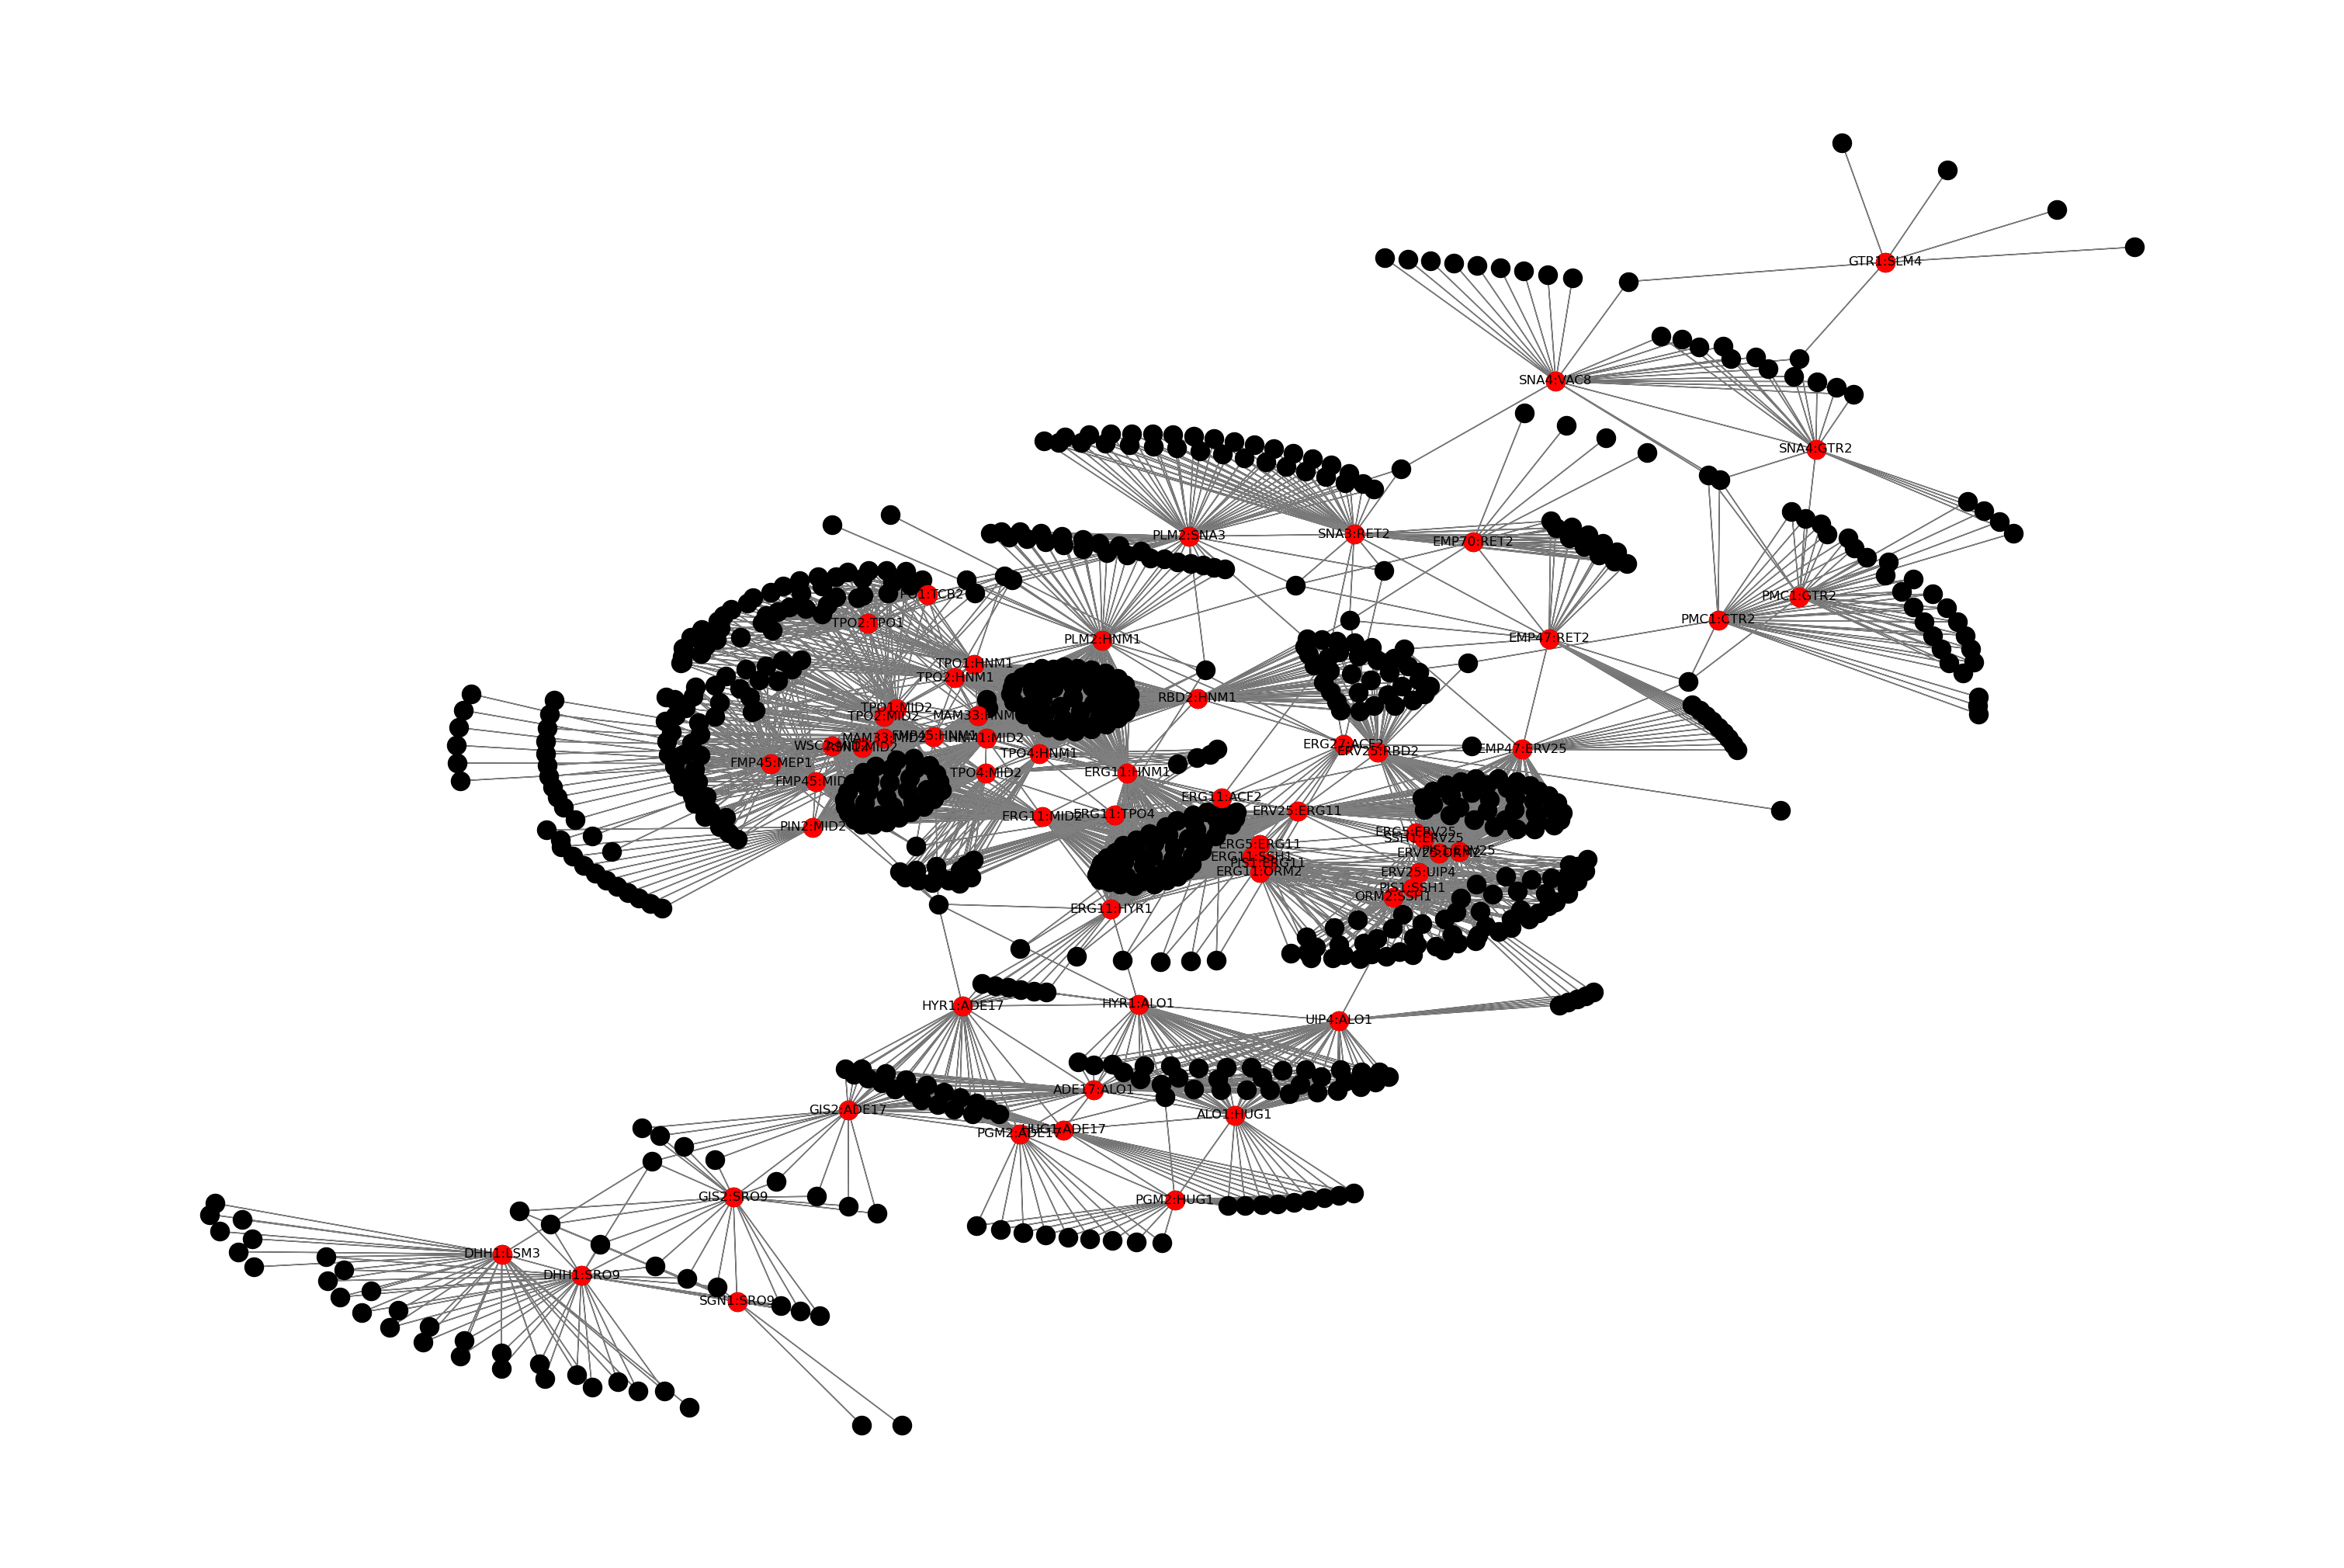

In [13]:
#### Draw the network 
node_list = [ ppi for ppi in all_PPIs if ppi in G.nodes ]
print(len(node_list))

f = plt.figure(figsize=(30,20))
nx.draw(G, pos=nx.nx_agraph.graphviz_layout(G, prog="neato"), node_color='black')
nx.draw_networkx_edges(G, pos=nx.nx_agraph.graphviz_layout(G, prog="neato"), edge_color='grey')
nx.draw_networkx_nodes(G, pos=nx.nx_agraph.graphviz_layout(G, prog="neato"), nodelist=node_list, node_color='red')
nx.draw_networkx_labels(G, pos=nx.nx_agraph.graphviz_layout(G, prog="neato"), labels={n: n for n in G if n in node_list})
plt.show()

In [14]:
#### Calculate the distance between each node 
dist_matrix = nx.floyd_warshall_numpy(G)
df = pd.DataFrame(dist_matrix, columns=G.nodes(), index=G.nodes())
df = df.reset_index().rename(columns={"index":"PPI"}).set_index('PPI')

In [15]:
df

,ERG27:ACF2,TGL4:ACF2,SNA3:ACF2,ERG7:ERG27,ACF2:SEL1,YEH1:ERG27,FAT1:ERG27,EHT1:ACF2,ERG7:ACF2,ERG11:ACF2,...,PLM2:SEC27,SWH1:VAC8,VAC8:HXT1,VAC8:MEH1,VAC8:IML1,DPP1:VAC8,FLC2:PLM2,PLM2:FLC1,PLM2:QDR2,PLM2:YOR1
PPI,,,,,,,,,,,,,,,,,,,,,
ERG27:ACF2,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,5.0,5.0,5.0,5.0,5.0,3.0,3.0,3.0,3.0
TGL4:ACF2,1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,...,4.0,6.0,6.0,6.0,6.0,6.0,4.0,4.0,4.0,4.0
SNA3:ACF2,1.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,...,2.0,4.0,4.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0
ERG7:ERG27,1.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,...,4.0,6.0,6.0,6.0,6.0,6.0,4.0,4.0,4.0,4.0
ACF2:SEL1,1.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,1.0,...,4.0,6.0,6.0,6.0,6.0,6.0,4.0,4.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DPP1:VAC8,5.0,6.0,4.0,6.0,6.0,6.0,6.0,6.0,6.0,5.0,...,4.0,2.0,2.0,2.0,2.0,0.0,4.0,4.0,4.0,4.0
FLC2:PLM2,3.0,4.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,...,2.0,4.0,4.0,4.0,4.0,4.0,0.0,2.0,2.0,2.0
PLM2:FLC1,3.0,4.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,...,2.0,4.0,4.0,4.0,4.0,4.0,2.0,0.0,2.0,2.0


In [16]:
#### Save the distance matrix
df.to_csv('../../../results/06_networks/distance_matrix_piQTLs.csv')

In [17]:
#### Subset the distance matrix with only the 61 PPIs 
filter =  [ ppi for ppi in all_PPIs if (ppi in G.nodes()) ] # and (ppi not in ['DHH1:LSM3','DHH1:SRO9'])
piQTLs = df.loc[[ ppi for ppi in all_PPIs if ppi in filter ], [ ppi for ppi in all_PPIs if ppi in filter ]]

In [18]:
stacked = piQTLs.stack()
piQTLs_distance_flat = stacked.reset_index().rename(columns={'PPI':'PPI1', 'level_1':'PPI2', 0:'distance'})
piQTLs_distance_flat

,PPI1,PPI2,distance
0,GTR1:SLM4,GTR1:SLM4,0.0
1,GTR1:SLM4,SNA4:GTR2,2.0
2,GTR1:SLM4,ERG11:HYR1,7.0
3,GTR1:SLM4,DHH1:LSM3,11.0
4,GTR1:SLM4,ERV25:ORM2,6.0
...,...,...,...
3716,ADE17:ALO1,PGM2:ADE17,1.0
3717,ADE17:ALO1,MAM33:MID2,4.0
3718,ADE17:ALO1,WSC2:MID2,4.0
3719,ADE17:ALO1,TPO2:HNM1,4.0


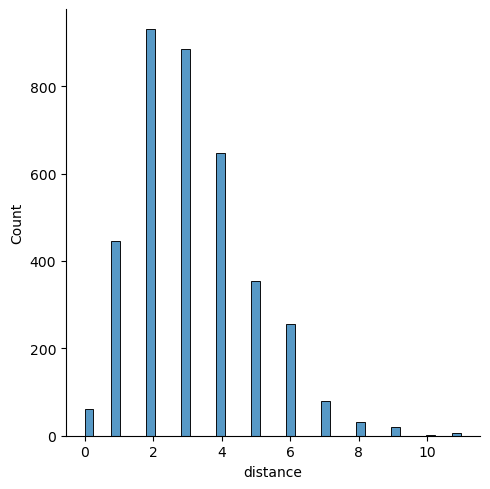

In [19]:
sns.displot(piQTLs_distance_flat['distance'])

In [20]:
len(G.nodes())

742

In [21]:
R = nx.erdos_renyi_graph(742, p=0.5)

## Hierarchical clustering of the PPI similarity network

/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/savvy/bin/miniforge3/envs/rapids-25.08/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


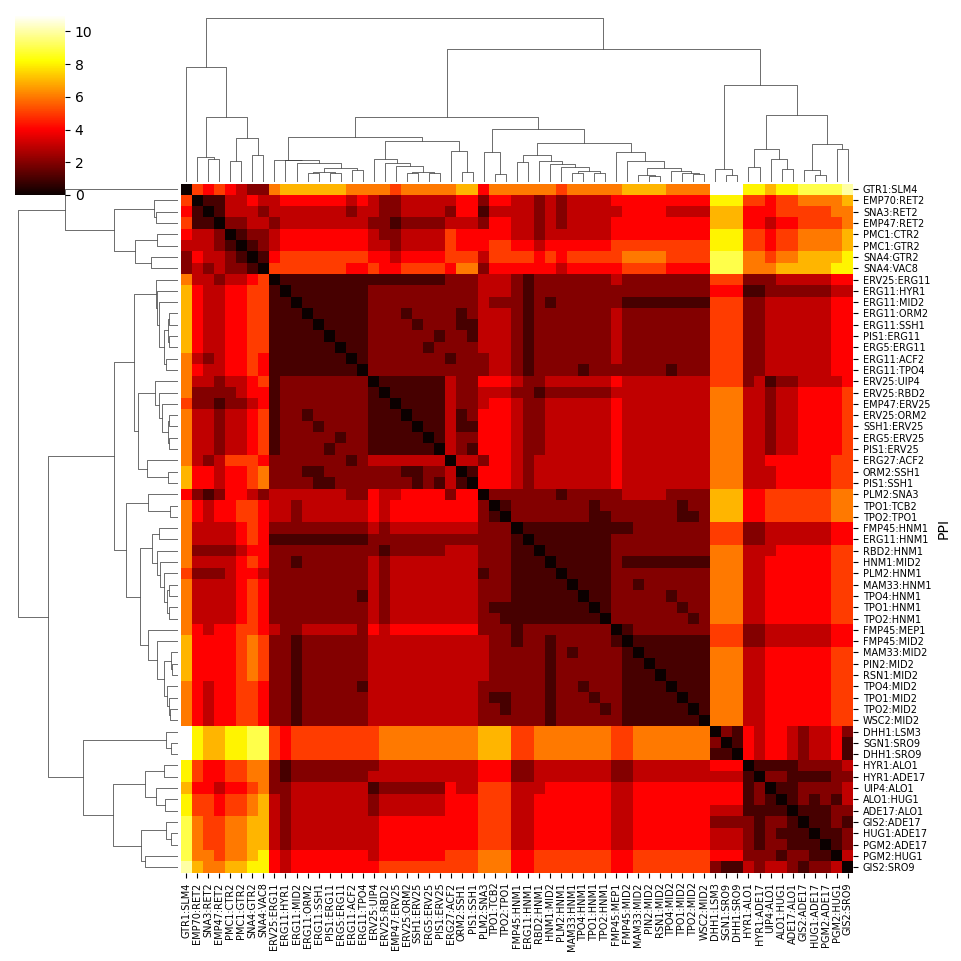

In [22]:
g = sns.clustermap(piQTLs, cmap='hot', method='complete', xticklabels=True, yticklabels=True)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize = 7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize = 7)
g.savefig("../../../figures/supp_figure_5/distance_clustermap_PPI_distance_network.eps", dpi=300)


In [ ]:
f = open('../../../results/06_networks/PPI_similarity_network_order.txt', 'w')
for PPI in piQTLs.index[g.dendrogram_row.reordered_ind]:
    f.write(f'{PPI}\n')
f.close()